## Customer Churn Exploratory Data Analysis (EDA)
### Project Overview

Customer churn refers to the loss of customers over time. High churn rates negatively impact revenue, profitability, and customer lifetime value. Understanding the drivers of churn is critical for designing effective retention strategies.

This notebook performs exploratory data analysis (EDA) on a customer churn dataset to:

- Examine the distribution of churn
- Identify key customer characteristics associated with churn
- Detect patterns and relationships between features
- Generate actionable business insights

The findings from this analysis will support data-driven decision-making aimed at reducing churn and improving customer retention.

In [1]:
# Import necessary libraies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu
from scipy.stats import chi2_contingency

### Data Loading and Initial Exploration
#### Objective
This section loads the dataset and performs an initial inspection to understand its structure, size, data types, and overall composition.

We examine:
1. Data Preview – To understand dataset structure, variable layout, and formatting.
2. Data Types & Missing Values – To assess variable types and detect any missing data.
3. Column Names Check – To identify inconsistencies in spelling or formatting.
4. Column Standardization – To remove extra spaces and ensure consistent variable referencing.
5. Duplicate Checks – To identify repeated columns, rows, or customer IDs, ensuring variable uniqueness and preserving dataset integrity.
6. Summary Statistics – To understand numeric variable behavior and detect anomalies.
7. Distribution Assessment – To examine shape, skewness, and spread of numeric variables.
8. Outlier Detection – To identify extreme values that could influence analysis or modeling.
9. Business Logic Validation – To verify that numeric values align with expected operational rules.
10. Unique Category Check – To confirm valid categorical entries and detect unexpected labels.
11. Category Frequency Analysis – To evaluate distributions, detect imbalances, and highlight key patterns (e.g., churn rates or contract types).

#### Key Findings
1. The dataset contains 20,000 records and 11 columns, comprising 5 numeric (tenure, monthly_charges, total_charges, support_calls) and 6 categorical (contract, payment_method, internet_service, tech_support, online_security, churn) variables; all fields are complete except internet_service (2,013 missing values), and data types are correctly assigned.
2. Column names were inspected and showed no typographical or spacing inconsistencies; they were standardized by stripping potential extra spaces as a precaution to improve readability and prevent referencing errors during EDA.
3. No duplicate columns, rows, or customer_id values were detected, confirming structural integrity and uniqueness of records.
4. Descriptive statistics indicate that tenure ranges from 1–72 months (median: 36), monthly_charges range from 20–120, total_charges increases consistently with tenure and monthly charges, and support_calls are generally low with a small subset of higher-frequency users.
5. Distribution analysis shows tenure and monthly_charges are relatively evenly distributed, while total_charges and support_calls exhibit right-skewed patterns consistent with accumulated billing and concentrated support usage.
6. Outlier assessment using the IQR method shows no extreme values in tenure or monthly_charges; total_charges has 0.89% outliers and support_calls 6.62%, both plausible within business context but relevant for modeling considerations.
7. Numeric variables comply with expected business logic: no negative or inappropriate zero values, integer integrity maintained for support_calls, tenure within the 72-month limit, and total_charges consistent with tenure × monthly_charges.
8. Categorical variables contain no unexpected values or typographical inconsistencies, indicating a clean categorical structure.
9. Frequency analysis shows contract skewed toward Month-to-month plans (~60%), payment_method evenly distributed, internet_service predominantly Fiber and DSL with ~10% missing values, limited uptake of tech_support and online_security, and a churn rate of approximately 34%.

#### Next Steps
- Address missing values in internet_service.
- Proceed to exploratory relationship analysis (churn vs predictors).


In [2]:
#Load the data
df = pd.read_csv('../Data/customer_churn_dataset.csv')

#Inspect the data
df.head()

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes


In [3]:
# i) Check for data types and missing data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       20000 non-null  int64  
 1   tenure            20000 non-null  int64  
 2   monthly_charges   20000 non-null  float64
 3   total_charges     20000 non-null  float64
 4   contract          20000 non-null  object 
 5   payment_method    20000 non-null  object 
 6   internet_service  17987 non-null  object 
 7   tech_support      20000 non-null  object 
 8   online_security   20000 non-null  object 
 9   support_calls     20000 non-null  int64  
 10  churn             20000 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 1.7+ MB


In [4]:
# ii) Check for typos and extra spaces in column names
df.columns

Index(['customer_id', 'tenure', 'monthly_charges', 'total_charges', 'contract',
       'payment_method', 'internet_service', 'tech_support', 'online_security',
       'support_calls', 'churn'],
      dtype='object')

In [5]:
# iii) Standardize column names by removing extra spaces
df.columns=df.columns.str.strip()

In [6]:
# iv) Check for duplicate columns
df.columns.duplicated()

array([False, False, False, False, False, False, False, False, False,
       False, False])

In [7]:
# v) Check for duplicated rows
df.duplicated().sum()

np.int64(0)

In [8]:
# vi) Check for duplicated customer IDS
df['customer_id'].duplicated().sum()

np.int64(0)

In [9]:
# vii) Inspect summary statistics for numeric data
df.describe()

,customer_id,tenure,monthly_charges,total_charges,support_calls
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,10000.500000,36.467450,70.010531,2543.979209,1.51255
std,5773.647028,20.773984,28.890239,1882.949804,1.23524
min,1.000000,1.000000,20.000000,20.230000,0.00000
25%,5000.750000,18.000000,45.210000,1045.837500,1.00000
50%,10000.500000,36.000000,70.090000,2096.495000,1.00000
75%,15000.250000,54.000000,95.072500,3690.337500,2.00000
max,20000.000000,72.000000,120.000000,8629.920000,8.00000


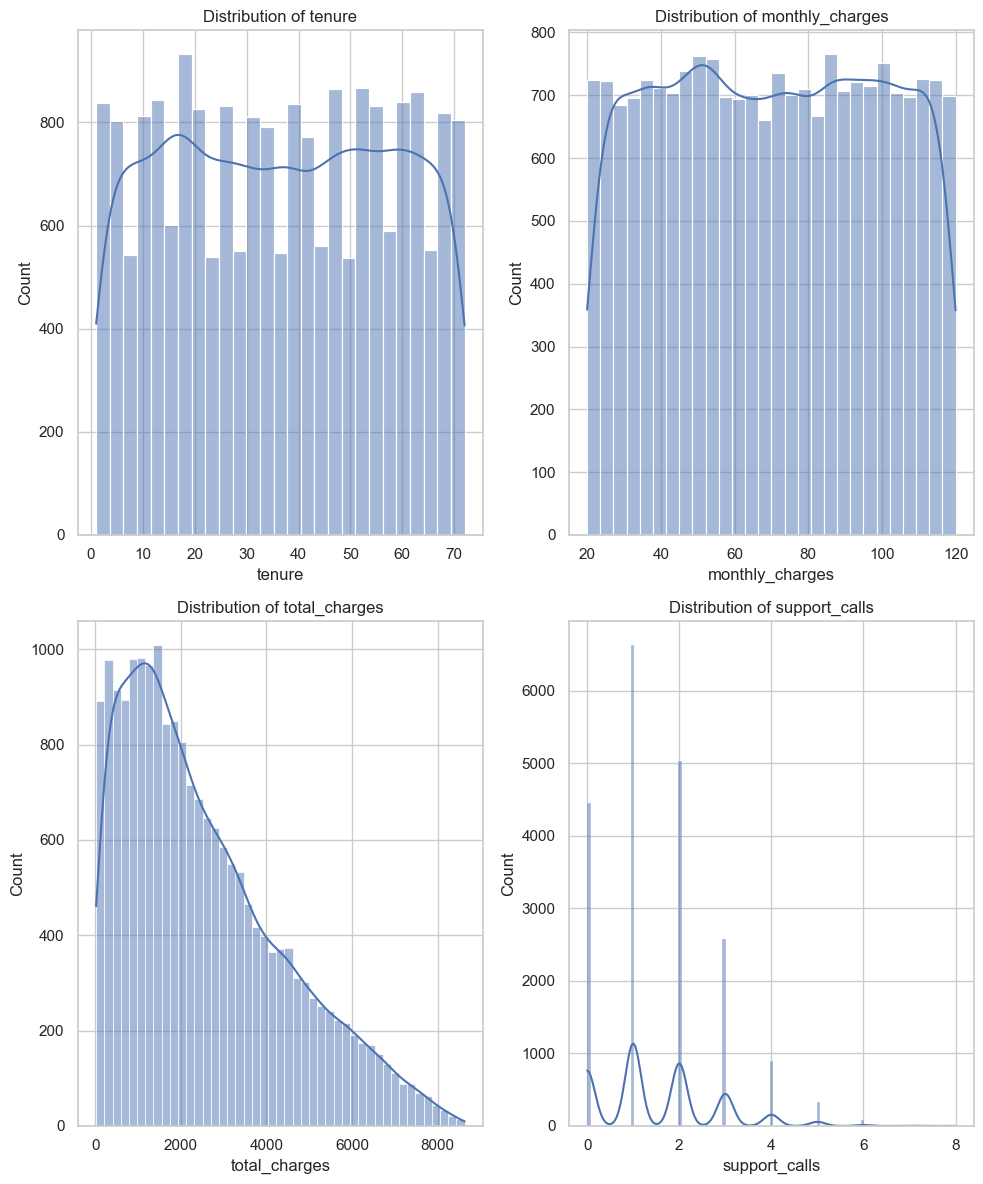

In [10]:
# viii) Check the distribution of numeric columns
# Select numeric columns (excluding identifier columns)
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Remove customer_id if present
if 'customer_id' in numeric_cols:
    numeric_cols.remove('customer_id')
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,12))
for i, col in enumerate (numeric_cols,1):
    plt.subplot(2,2,i)
    sns.histplot(x=col, data=df, kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig(f"Numeric_cols_hist.png") 
plt.show()

In [11]:
# ix) Check for outliers 
# Detect outliers using IQR method for all numeric columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) | 
        (df[col] > upper_bound)
    ]
    
    outlier_count = outliers.shape[0]
    outlier_percentage = (outlier_count / len(df)) * 100
    
    outlier_summary.append({
        "Column": col,
        "Outlier Count": outlier_count,
        "Outlier %": round(outlier_percentage, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Column,Outlier Count,Outlier %
0,tenure,0,0.00
1,monthly_charges,0,0.00
2,total_charges,177,0.89
3,support_calls,1325,6.62


In [12]:
# x) Check for business logic consistency
def validate_customer_churn(df):
    results = {
        'negative_tenure': (df['tenure'] < 0).sum(),
        'negative_monthly_charges': (df['monthly_charges'] < 0).sum(),
        'negative_total_charges': (df['total_charges'] < 0).sum(),
        'negative_support_calls': (df['support_calls'] < 0).sum(),
        'zero_tenure': (df['tenure'] == 0).sum(),
        'zero_monthly_charges': (df['monthly_charges'] == 0).sum(),
        'non_integer_support_calls': (df['support_calls'] % 1 != 0).sum(),
        'tenure_exceeds_72_months': (df['tenure'] > 72).sum(),
        'total_charge_mismatch': (
            (df['total_charges'] - (df['tenure'] * df['monthly_charges'])).abs() > 1
        ).sum()
    }
    
    report = pd.DataFrame.from_dict(results, orient='index', columns=['issue_count'])
    
    return report
validate_customer_churn(df)

,issue_count
negative_tenure,0
negative_monthly_charges,0
negative_total_charges,0
negative_support_calls,0
zero_tenure,0
zero_monthly_charges,0
non_integer_support_calls,0
tenure_exceeds_72_months,0
total_charge_mismatch,0


In [13]:
# xii) Check for unique values
def check_unique_values(df):
    """
    Check and display unique values for all categorical columns in a dataframe.
    """
    # Select categorical columns
    categorical_cols = df.select_dtypes(include='object').columns.tolist()
    
    # Loop through categorical columns
    for col in categorical_cols:
        unique_vals = df[col].unique()
        print(f"Column: {col}")
        print(f"Number of unique values: {len(unique_vals)}")
        print(f"Unique values: {unique_vals}\n")
check_unique_values(df)

Column: contract
Number of unique values: 3
Unique values: ['Month-to-month' 'One year' 'Two year']

Column: payment_method
Number of unique values: 4
Unique values: ['Credit' 'Debit' 'Cash' 'UPI']

Column: internet_service
Number of unique values: 3
Unique values: ['DSL' 'Fiber' nan]

Column: tech_support
Number of unique values: 2
Unique values: ['No' 'Yes']

Column: online_security
Number of unique values: 2
Unique values: ['Yes' 'No']

Column: churn
Number of unique values: 2
Unique values: ['No' 'Yes']



In [14]:
# xiii) Check value counts
def value_counts_categorical(df):
    """
    Print value counts for all categorical columns in the dataframe
    """
    #Select categorical columns
    categorical_cols = df.select_dtypes(include = 'object').columns.tolist()
    
    # Loop through each categorical column
    for col in categorical_cols:
        print(f"Column: {col}")
        print(df[col].value_counts(dropna=False))
        print("\n" + "-"*50 + "\n")
value_counts_categorical(df)

Column: contract
contract
Month-to-month    11942
One year           4990
Two year           3068
Name: count, dtype: int64

--------------------------------------------------

Column: payment_method
payment_method
Credit    5026
Debit     5025
Cash      4995
UPI       4954
Name: count, dtype: int64

--------------------------------------------------

Column: internet_service
internet_service
Fiber    10064
DSL       7923
NaN       2013
Name: count, dtype: int64

--------------------------------------------------

Column: tech_support
tech_support
No     13031
Yes     6969
Name: count, dtype: int64

--------------------------------------------------

Column: online_security
online_security
No     12008
Yes     7992
Name: count, dtype: int64

--------------------------------------------------

Column: churn
churn
No     13157
Yes     6843
Name: count, dtype: int64

--------------------------------------------------



### Data Cleaning: Handling Missing Values
#### Objective
Address missing data in internet_service while preserving dataset integrity and minimizing analytical bias.

We examine:

- Extent of Missingness and Feasibility of Removal – To determine whether deletion is statistically appropriate.
- Pattern of Missingness – To assess whether missing values follow a systematic (MAR/MNAR) structure.
- Implications for Analysis – To evaluate potential bias if the variable were removed.

#### Key Findings
- The internet_service variable contains 10.065% missing values, exceeding the common 5% threshold for safe deletion.
- Removing the variable would eliminate important information about customer subscriptions and related services (tech_support, online_security), potentially biasing churn analysis.
- Evaluation of the missingness pattern indicates a mixed MAR/MNAR structure, as only 40% of missing entries align with customers who do not use related services.

#### Cleaning Action
- Missing values in internet_service were recoded and replaced with a new category labeled “Unknown” to preserve completeness while maintaining analytical transparency.

**Status:** The dataset is clean and ready for further analysis.

In [15]:
# Identify percentage of missing data
missing_percentage = df['internet_service'].isna().sum()/len(df) * 100
missing_percentage

np.float64(10.065)

In [16]:
# Identify kind of missingness
# i) Select rows where internet service is missing
missing_internet = df[df['internet_service'].isna()]
missing_internet.head()

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
11,12,38,49.50,1881.00,Month-to-month,Debit,NaN,No,Yes,1,Yes
32,33,51,90.90,4635.90,Month-to-month,Credit,NaN,No,No,6,Yes
45,46,44,74.24,3266.56,Two year,Cash,NaN,No,No,1,No
57,58,63,103.03,6490.89,Month-to-month,UPI,NaN,No,No,1,Yes
67,68,40,63.91,2556.40,Month-to-month,UPI,NaN,Yes,No,0,Yes


In [17]:
# ii) Validate if missing data in interenet services corresponds to a 'No' in tech_support and online_security
missing_internet[['tech_support','online_security']].value_counts(dropna=False)

tech_support  online_security
No            No                 815
              Yes                529
Yes           No                 414
              Yes                255
Name: count, dtype: int64

In [18]:
# iii) Percentage of missing internet_service rows with 'No' for both tech_support and online_security
valid_no_internet = missing_internet[
    (missing_internet['tech_support'] == 'No') & 
    (missing_internet['online_security'] == 'No')
]

percentage_no_internet = len(valid_no_internet) / len(missing_internet) * 100
print(f"{percentage_no_internet:.2f}% of missing internet_service rows have No tech_support and No online_security")

40.49% of missing internet_service rows have No tech_support and No online_security


In [19]:
# iv) Replace missing values in internet_service with 'Unknown')
df['internet_service']=df['internet_service'].fillna('Unknown')

#Verify that there are no missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       20000 non-null  int64  
 1   tenure            20000 non-null  int64  
 2   monthly_charges   20000 non-null  float64
 3   total_charges     20000 non-null  float64
 4   contract          20000 non-null  object 
 5   payment_method    20000 non-null  object 
 6   internet_service  20000 non-null  object 
 7   tech_support      20000 non-null  object 
 8   online_security   20000 non-null  object 
 9   support_calls     20000 non-null  int64  
 10  churn             20000 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 1.7+ MB


### Exploratory Relationship Analysis : Numeric Data
#### 1. Numeric Variables vs. Churn
#### Objective
Assess the relationship between churn and predictor variables to identify significant drivers of customer attrition.

We Examine:
- Distributional differences in numeric predictors across churn groups (boxplots).
- Central tendency differences (mean/median comparison).
- Statistical significance of group differences (independent t-test and Mann–Whitney U test, selected based on distributional properties).

#### Key Findings: Numeric Variables vs Churn (Boxplot Analysis)
1. Tenure – Boxplots show that retained customers have a slightly higher median tenure than churned customers, with similar interquartile ranges and no extreme outliers. This indicates consistent but moderate separation, suggesting that shorter customer lifespan is associated with higher churn likelihood.
2. Monthly Charges – A clear visual separation is observed, with churned customers exhibiting a substantially higher median monthly charge compared to retained customers. The spreads are similar and free from extreme outliers, indicating a systematic pricing-related difference rather than variability-driven distortion.
3. Total Charges – Median differences between groups are minimal; however, retained customers display several upper-end outliers, reflecting long-tenure customers with accumulated billing. This suggests total charges may reflect customer longevity more than immediate churn risk.
4. Support Calls – While median values are similar across groups, churned customers exhibit a wider interquartile range, indicating greater variability in service interactions. This suggests that elevated or inconsistent support usage may signal dissatisfaction preceding churn.

Overall, visual inspection confirms strong separation for monthly_charges and tenure, moderate variability-driven differentiation for support_calls, and limited central separation for total_charges.

Tenure and monthly_charges exhibit approximately symmetric distributions hence will be evaluated further using independent t-tests, while total_charges and support_calls display right-skewed patterns and will be assessed using Mann–Whitney U tests to account for non-normality.

#### Key Findings: Numeric Variables vs Churn (Statistical Significance  Analysis)
1. Tenure – The independent t-test produced a T-statistic of 12.16 with a p-value < 0.001, indicating a statistically significant difference in tenure between churned and retained customers. Customers who churn have significantly shorter tenure, suggesting early lifecycle vulnerability.
2. Monthly Charges – The t-test yielded a T-statistic of -35.53 with a p-value < 0.001, confirming a highly significant difference in average monthly charges across churn groups. Churned customers pay significantly higher monthly charges, indicating price sensitivity or dissatisfaction among higher-paying segments.
3. Total Charges – The Mann–Whitney U test returned a U-statistic of 43,068,671 with a p-value < 0.001, indicating a significant distributional difference between churn groups. However, the effect appears driven more by accumulated billing patterns rather than clear central separation, suggesting moderate predictive relevance.
4. Support Calls – The Mann–Whitney U test produced a U-statistic of 35,642,438 with a p-value < 0.001, confirming a significant difference in support call distributions. Churned customers exhibit greater variability in support usage, indicating behavioral dissatisfaction signals.

Overall,among numeric variables, monthly_charges and tenure exhibit the strongest differentiation, support_calls demonstrates moderate behavioral relevance, and total_charges reflects structurally influenced variation tied to customer longevity.


#### Key Business Insights
1. Shorter-tenure customers are at higher risk of churn: Early-stage customers are more likely to leave, highlighting the importance of onboarding, engagement, and early retention strategies to reduce early churn.
2. Higher-paying customers are more sensitive to churn: Customers with higher monthly charges are disproportionately represented among churners, suggesting that pricing perception, value delivery, or premium plan satisfaction should be carefully monitored.
3. Support usage signals potential dissatisfaction: Churned customers show greater variability in support interactions, indicating that increased or inconsistent support requests can act as early warning signals for churn and should inform proactive customer service interventions.
4. Total charges reflect customer longevity rather than immediate churn risk: Differences in total charges are mostly due to accumulated billing from longer-tenure customers, suggesting that total charges are less predictive of immediate churn but useful for understanding lifetime value.


#### 2. Correlation Analysis: Numeric Variables
#### Objective
Assess linear relationships among numeric predictors to detect multicollinearity and validate business logic.

We Examine:
- Strength and direction of linear relationships among numeric variables (correlation matrix and heatmap).
- Logical consistency between billing-related variables and tenure.

#### Key Findings
1. Tenure and Total Charges show a strong positive correlation (r = 0.77), confirming expected business logic that total charges accumulate over time.
2. Monthly Charges and Total Charges exhibit a moderate positive correlation (r = 0.55), indicating that pricing level contributes meaningfully to accumulated billing.
3. Tenure and Monthly Charges show negligible correlation (r ≈ -0.02), suggesting that subscription duration and pricing tier are largely independent decisions.
4. Support Calls demonstrate near-zero correlation with all other numeric variables, indicating that service interaction behavior operates independently from billing and tenure characteristics.
5. No extremely high correlations (> 0.80) were observed, suggesting limited risk of multicollinearity among numeric predictors.

Overall, correlation analysis confirms strong alignment between tenure and total_charges, moderate contribution of monthly_charges to total billing, independence between tenure and pricing decisions, and minimal relationship between support_calls and other numeric variables, with no indication of multicollinearity.

#### Key Business Insights
1. Longer-tenure customers drive most revenue: Retaining customers over time has a direct impact on total billing, so retention strategies should prioritize long-term engagement.
2. Higher-priced plans meaningfully increase total revenue: Encouraging customers to adopt premium plans can boost revenue independently of how long they stay.
3. Pricing and loyalty are independent: Customers do not necessarily move to higher pricing plans the longer they stay, meaning retention strategies should target all customers regardless of plan, while pricing or upselling initiatives should be deliberate and value-driven rather than assumed to occur naturally with tenure.
4. Support usage is independent of customer value: High or low service interactions are not tied to billing or tenure, meaning support initiatives should focus on satisfaction rather than revenue targeting.



In [20]:
#Check for relationship between numerical variables and churn
df.groupby('churn')[['tenure','monthly_charges','total_charges','support_calls']].agg('median','mean')

,tenure,monthly_charges,total_charges,support_calls
churn,,,,
No,38.0,62.33,2030.40,1.0
Yes,33.0,86.89,2271.36,2.0


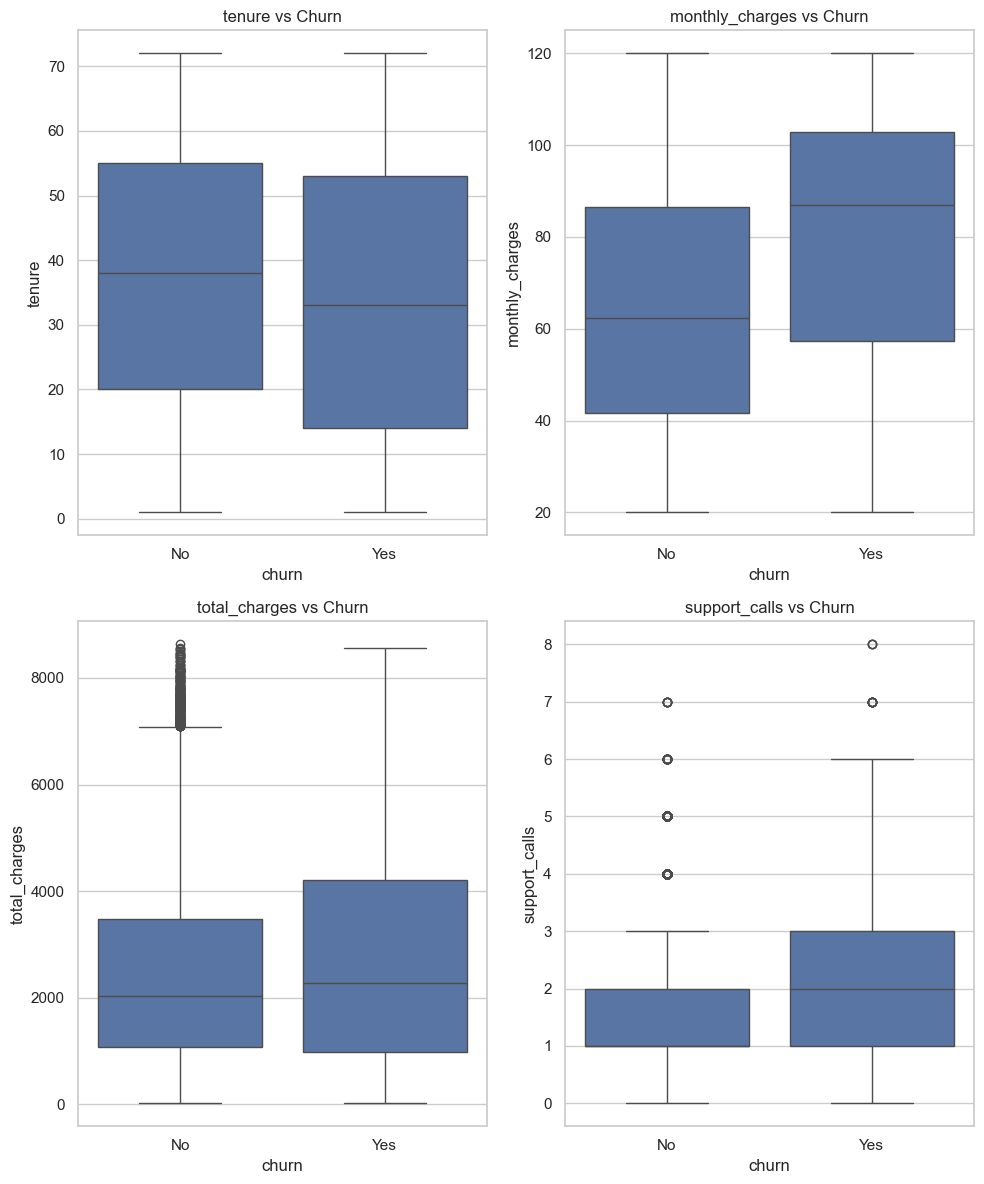

In [21]:
# Check the relationship between numeric variables and churn
numeric_cols = df [['tenure','monthly_charges','total_charges','support_calls']]
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,12))
for i, col in enumerate (numeric_cols,1):
    plt.subplot(2,2,i)
    sns.boxplot(x='churn', y=col, data=df)
    plt.title(f'{col} vs Churn')
plt.tight_layout()
plt.savefig(f"Numeric_cols_box.png") 
plt.show()


In [22]:
# Compare mean values of churned vs. non-churned customers for normally distributed numeric variables
# i) Define hypotheses:
#     H0: The mean values of churned and non-churned customers are equal
#     H1: The mean values of churned and non-churned customers are different
# ii) Set significance level
alpha = 0.05
# iii) Calculate t_statistic p_value
numeric_vars = ['tenure','monthly_charges']
for var in numeric_vars:
    group_no = df[df['churn']=='No'][var]
    group_yes = df[df['churn']=='Yes'][var]
    
    t_stat, p_value = ttest_ind(group_no, group_yes, equal_var=False)
    print(f"{var.capitalize()} - T-statistic: {t_stat:.2f}, P-value: {p_value:.4f}")
# iv) interpret the results
if p_value <= alpha:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')


Tenure - T-statistic: 12.16, P-value: 0.0000
Monthly_charges - T-statistic: -35.53, P-value: 0.0000
Reject the null hypothesis


In [23]:
# Compare distributions of churned vs. non-churned customers for numeric variables
# i) Define hypotheses:
#     H0: The distributions of churned and non-churned customers are the same
#     H1: The distributions of churned and non-churned customers are different
# ii) Set significance level
alpha = 0.05
# iii) Calculate t_statistic p_value
numeric_vars = ['total_charges','support_calls']
for var in numeric_vars:
    group_no = df[df['churn']=='No'][var]
    group_yes = df[df['churn']=='Yes'][var]
    
    u_stat, p_value = mannwhitneyu(group_no, group_yes, alternative='two-sided')
    print(f"{var.capitalize()} - U-statistic: {u_stat:.2f}, P-value: {p_value:.4f}")
# iv) interpret the results
if p_value <= alpha:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

Total_charges - U-statistic: 43068671.00, P-value: 0.0000
Support_calls - U-statistic: 35642438.00, P-value: 0.0000
Reject the null hypothesis


In [24]:
# Check relationship between numeric variables
# i) Compute correlation matrix for numeric variables
numeric_cols = ['tenure', 'monthly_charges', 'total_charges', 'support_calls']
corr_matrix = df[numeric_cols].corr()
corr_matrix

,tenure,monthly_charges,total_charges,support_calls
tenure,1.000000,-0.015207,0.765916,-0.002808
monthly_charges,-0.015207,1.000000,0.546700,-0.002381
total_charges,0.765916,0.546700,1.000000,-0.006483
support_calls,-0.002808,-0.002381,-0.006483,1.000000


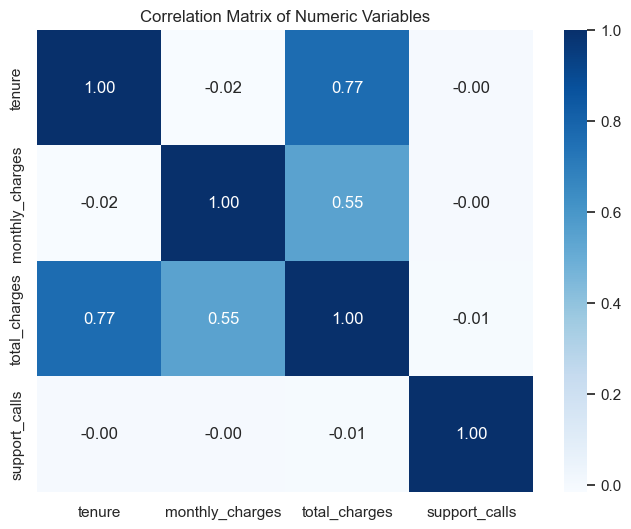

In [25]:
# ii) Visualize correlation between numeric variables
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Matrix of Numeric Variables")
plt.savefig(f'Numeric_cols_heatmap.png')
plt.show()

### Exploratory Relationship Analysis: Categorical Variables vs Churn
#### Objective
Assess whether churn is statistically associated with categorical service attributes.

#### We Examine:
- Churn rate across categories.(crosstab)
- Statistical dependence (Chi-square test).
- Strength of association (Cramér’s V).

#### Key Findings
1. Cross-tabulation analysis indicates substantial variation in churn rates across contract types, with Month-to-month customers exhibiting a churn rate of 43.18% compared to approximately 21% for one-year and two-year contracts.
2. Chi-square testing confirms a statistically significant association between contract type and churn (p < 0.001), with a moderate effect size (Cramér’s V = 0.23), indicating meaningful predictive relevance.
3. Payment_method shows nearly identical churn rates across categories (~34%), with no statistically significant association detected (p = 0.963) and negligible effect size (Cramér’s V = 0.004), suggesting limited analytical value.
4. Internet_service categories exhibit similar churn rates (33–35%), with no statistically significant dependence observed (p = 0.505) and minimal effect size (Cramér’s V = 0.008).
5. Tech_support demonstrates clear differentiation, with customers lacking support exhibiting a churn rate of 41.39% compared to 20.79% among those subscribed; this relationship is statistically significant (p < 0.001) with moderate effect size (Cramér’s V = 0.207).
6. Online_security shows negligible variation in churn rates across categories (~34%), with no statistically significant association detected (p = 0.377) and minimal effect size (Cramér’s V = 0.006).

Overall, among categorical predictors, contract type and tech_support exhibit meaningful associations with churn, while payment_method, internet_service, and online_security demonstrate limited predictive influence.

#### Key Business Insights
1. Longer-term contracts reduce churn risk: Customers on one-year or two-year contracts churn much less than month-to-month subscribers. This suggests that promoting or incentivizing longer-term contracts can help stabilize revenue and retain customers.
2. Tech support is a critical retention lever: Customers without tech support churn at double the rate of those with support. Investing in better tech support availability and communication can significantly reduce churn.
3. Other services and payment methods have little effect on churn: Internet service type, online security, and payment method show negligible differences in churn. This indicates that focusing retention strategies on these areas may have limited impact, allowing resources to be allocated more effectively toward contract management and tech support.

In [26]:
# Check the relationship between categorical variables and churn
# i) check for percentage of churn within each contract type
categorical_vars = ['contract', 'payment_method', 'internet_service', 'tech_support', 'online_security']
for var in categorical_vars:
    crosstab = pd.crosstab(df[var], df['churn'], normalize='index') * 100
    print("\nChurn Rate (% within category):")
    print(crosstab.round(2))


Churn Rate (% within category):
churn              No    Yes
contract                    
Month-to-month  56.82  43.18
One year        79.08  20.92
Two year        79.07  20.93

Churn Rate (% within category):
churn              No    Yes
payment_method              
Cash            65.95  34.05
Credit          65.82  34.18
Debit           65.89  34.11
UPI             65.48  34.52

Churn Rate (% within category):
churn                No    Yes
internet_service              
DSL               66.14  33.86
Fiber             65.71  34.29
Unknown           64.78  35.22

Churn Rate (% within category):
churn            No    Yes
tech_support              
No            58.61  41.39
Yes           79.21  20.79

Churn Rate (% within category):
churn               No    Yes
online_security              
No               66.03  33.97
Yes              65.42  34.58


In [27]:
# ii) Check for statistically significant association between churn and categorical variables
# a) Set the hpothesis
# Ho: There is no significant association with churn
# H1: There is a significant association with churn
# b) Set the significance level
alpha = 0.05
# c) Calculate t_statistic p_value
categorical_vars = ['contract', 'payment_method', 'internet_service', 'tech_support', 'online_security']
for var in categorical_vars: 
    contingency = pd.crosstab(df[var], df['churn'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    print("\nChi-square Test:")
    print(f"Chi-square statistic: {chi2:.2f}")
    print(f"P-value: {p:.6f}")
    # interpret the results
    if p <= alpha:
        print('Reject the null hypothesis')
    else:
        print('Fail to reject the null hypothesis')


Chi-square Test:
Chi-square statistic: 1059.25
P-value: 0.000000
Reject the null hypothesis

Chi-square Test:
Chi-square statistic: 0.29
P-value: 0.962596
Fail to reject the null hypothesis

Chi-square Test:
Chi-square statistic: 1.37
P-value: 0.505151
Fail to reject the null hypothesis

Chi-square Test:
Chi-square statistic: 855.28
P-value: 0.000000
Reject the null hypothesis

Chi-square Test:
Chi-square statistic: 0.78
P-value: 0.376935
Fail to reject the null hypothesis


In [28]:
# iii) Check the strength of association between churn and categorical variables
def cramers_v(x, y):
    """Calculate Cramér's V statistic for categorical-categorical association."""
    contingency_table = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    return np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

# List of categorical variables
categorical_vars = ['contract', 'payment_method', 'internet_service', 'tech_support', 'online_security']

# Loop through variables and calculate Cramér's V vs churn
for var in categorical_vars:
    cv = cramers_v(df[var], df['churn'])
    print(f"Cramér's V between {var} and churn: {cv:.3f}")

Cramér's V between contract and churn: 0.230
Cramér's V between payment_method and churn: 0.004
Cramér's V between internet_service and churn: 0.008
Cramér's V between tech_support and churn: 0.207
Cramér's V between online_security and churn: 0.006


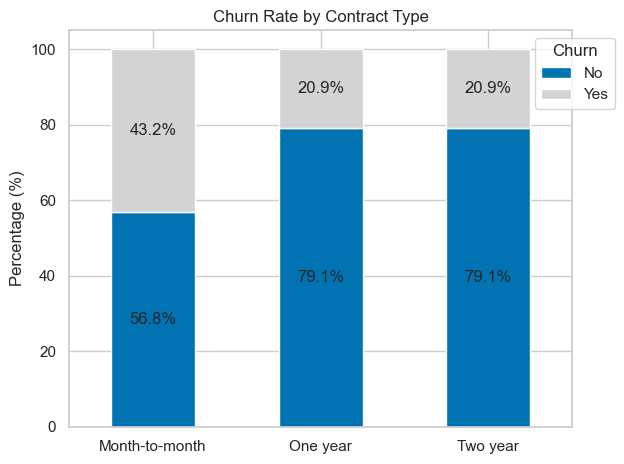

In [60]:
# iv) Visualize statitically significant Categorical drivers of Churn
# a) Contract vs Churn (100% stacked)
contract_churn = pd.crosstab(df['contract'], df['churn'], normalize='index') * 100

ax = contract_churn.plot(
    kind='bar',
    stacked=True,
    color= ['#0173B2','#D3D3D3']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.title('Churn Rate by Contract Type')
plt.xlabel('')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
ax.legend(['No', 'Yes'], title='Churn', loc='upper right', bbox_to_anchor=(1.1,1))

plt.tight_layout()
plt.savefig(f"Churn_Rate_by_Contract_Type.png")
plt.show()

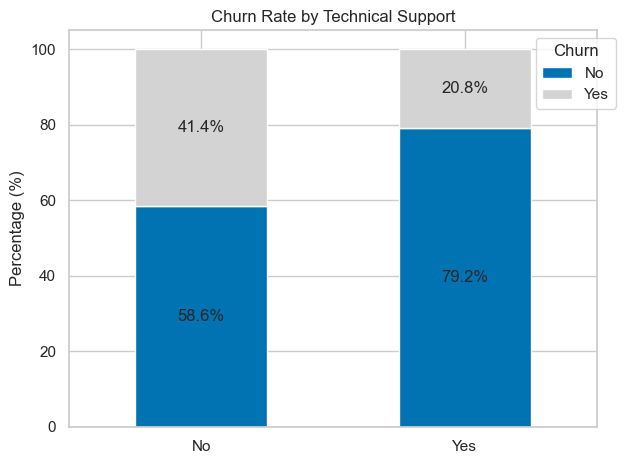

In [61]:
# b) Technical Support vs Churn (100% stacked)

tech_churn = pd.crosstab(df['tech_support'], df['churn'], normalize='index') * 100

ax = tech_churn.plot(
    kind='bar',
    stacked=True,
    color=['#0173B2','#D3D3D3']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

ax.set_title('Churn Rate by Technical Support')
ax.set_xlabel('')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

ax.legend(['No', 'Yes'], title='Churn', loc='upper right', bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.savefig(f"Churn_Rate_by_Technical_Support.png")
plt.show()